# Student Performance Prediction — Model Development

This notebook develops and evaluates machine-learning models for predicting students' final academic performance (`G3`).

Two prediction scenarios are evaluated:

1. **Early Prediction** — predicts final performance using demographic, behavioral, family, and educational features while excluding previous grades (`G1` and `G2`).
2. **Progressive Prediction** — includes previous academic performance (`G1` and `G2`) to determine how much predictive accuracy improves as additional academic information becomes available.

A baseline predictor, Decision Tree Regressor, and Random Forest Regressor are compared using Mean Absolute Error (MAE) and R².

## Import Libraries

The modeling workflow uses scikit-learn for data splitting, preprocessing, model training, and evaluation. Pandas and NumPy are used for data manipulation, while Matplotlib is used to visualize model performance.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

## Load the Dataset

The same UCI Student Performance dataset used during exploratory data analysis is loaded for model development. The target variable is `G3`, representing the student's final grade.

In [2]:
DATA_PATH = "../data/raw/student-mat.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## Define the Prediction Target

The objective is formulated as a regression problem because `G3` is a numerical final grade ranging from 0 to 20.

The target variable is separated from the predictor variables before constructing the two prediction scenarios.

In [3]:
TARGET = "G3"

y = df[TARGET]

X = df.drop(columns=[TARGET])

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (395, 32)
Target shape: (395,)


## Define Prediction Scenarios

Two feature sets are created to evaluate student performance prediction at different stages.

### Scenario 1 — Early Prediction

`G1` and `G2` are excluded. This scenario evaluates how well final performance can be predicted using student background, behavioral, family, and educational characteristics before previous course grades are available.

### Scenario 2 — Progressive Prediction

`G1` and `G2` are retained. This scenario evaluates how prediction changes when previous academic performance becomes available.

Comparing these scenarios helps quantify the predictive value contributed by earlier grades.

In [4]:
X_early = X.drop(columns=["G1", "G2"])

X_progressive = X.copy()

print("Early prediction features:", X_early.shape[1])
print("Progressive prediction features:", X_progressive.shape[1])

Early prediction features: 30
Progressive prediction features: 32


## Train-Test Split

The dataset is divided into training and testing sets using an 80/20 split.

The same row indices are used for both prediction scenarios so that Early and Progressive models are evaluated on identical students. This allows differences in performance to be attributed to the available features rather than different train-test samples.

A fixed random state is used to make the experiment reproducible.

In [5]:
train_indices, test_indices = train_test_split(
    df.index,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_early_train = X_early.loc[train_indices]
X_early_test = X_early.loc[test_indices]

X_progressive_train = X_progressive.loc[train_indices]
X_progressive_test = X_progressive.loc[test_indices]

y_train = y.loc[train_indices]
y_test = y.loc[test_indices]

print("Training students:", len(train_indices))
print("Testing students:", len(test_indices))

print("\nEarly prediction:")
print("Training shape:", X_early_train.shape)
print("Testing shape:", X_early_test.shape)

print("\nProgressive prediction:")
print("Training shape:", X_progressive_train.shape)
print("Testing shape:", X_progressive_test.shape)

Training students: 316
Testing students: 79

Early prediction:
Training shape: (316, 30)
Testing shape: (79, 30)

Progressive prediction:
Training shape: (316, 32)
Testing shape: (79, 32)


## Identify Feature Types

The dataset contains both numerical and categorical predictors.

Numerical features can be passed directly to the tree-based models, while categorical features must first be converted into a numerical representation. One-hot encoding will be used for categorical variables.

In [6]:
early_numerical = X_early.select_dtypes(include=np.number).columns.tolist()
early_categorical = X_early.select_dtypes(exclude=np.number).columns.tolist()

progressive_numerical = X_progressive.select_dtypes(include=np.number).columns.tolist()
progressive_categorical = X_progressive.select_dtypes(exclude=np.number).columns.tolist()

print("EARLY PREDICTION")
print("Numerical:", len(early_numerical))
print("Categorical:", len(early_categorical))

print("\nPROGRESSIVE PREDICTION")
print("Numerical:", len(progressive_numerical))
print("Categorical:", len(progressive_categorical))

EARLY PREDICTION
Numerical: 13
Categorical: 17

PROGRESSIVE PREDICTION
Numerical: 15
Categorical: 17


## Preprocessing Pipeline

Categorical features are transformed using one-hot encoding so that they can be processed by scikit-learn regression models.

`handle_unknown="ignore"` ensures that a categorical value appearing in the test data but not in the training data does not cause prediction to fail.

Numerical features are passed through without transformation because Decision Trees and Random Forests do not require feature scaling.

In [7]:
early_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            early_categorical
        ),
        (
            "numerical",
            "passthrough",
            early_numerical
        )
    ]
)

progressive_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            progressive_categorical
        ),
        (
            "numerical",
            "passthrough",
            progressive_numerical
        )
    ]
)

## Baseline Model

A baseline regression model is established before training machine-learning models.

The baseline predicts the mean final grade observed in the training data for every student. Decision Tree and Random Forest models should outperform this simple strategy to demonstrate useful predictive capability.

In [8]:
baseline_model = DummyRegressor(strategy="mean")

baseline_model.fit(X_early_train, y_train)

baseline_predictions = baseline_model.predict(X_early_test)

baseline_mae = mean_absolute_error(y_test, baseline_predictions)
baseline_r2 = r2_score(y_test, baseline_predictions)

print(f"Baseline MAE: {baseline_mae:.3f}")
print(f"Baseline R²: {baseline_r2:.3f}")

Baseline MAE: 3.646
Baseline R²: -0.010


## Decision Tree Regression

A Decision Tree Regressor is trained as the first machine-learning model.

Decision Trees learn nonlinear relationships by recursively splitting the feature space into regions that produce increasingly similar target values.

The first model uses the **Early Prediction** feature set, which excludes `G1` and `G2`. Its performance will be compared against the baseline model using MAE and R².

In [9]:
early_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", early_preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

early_tree_pipeline.fit(X_early_train, y_train)

early_tree_predictions = early_tree_pipeline.predict(X_early_test)

early_tree_mae = mean_absolute_error(
    y_test,
    early_tree_predictions
)

early_tree_r2 = r2_score(
    y_test,
    early_tree_predictions
)

print(f"Early Decision Tree MAE: {early_tree_mae:.3f}")
print(f"Early Decision Tree R²: {early_tree_r2:.3f}")

Early Decision Tree MAE: 3.595
Early Decision Tree R²: -0.116


### Decision Tree Training Performance

Decision Trees can easily overfit small datasets by learning highly specific patterns from the training observations.

To investigate potential overfitting, model performance is measured separately on the training and testing sets. A large difference between training and testing performance would indicate that the model is not generalizing well to unseen students.

In [10]:
early_tree_train_predictions = early_tree_pipeline.predict(
    X_early_train
)

early_tree_train_mae = mean_absolute_error(
    y_train,
    early_tree_train_predictions
)

early_tree_train_r2 = r2_score(
    y_train,
    early_tree_train_predictions
)

print("EARLY DECISION TREE")
print("-------------------")

print(f"Training MAE: {early_tree_train_mae:.3f}")
print(f"Training R²:  {early_tree_train_r2:.3f}")

print()

print(f"Testing MAE:  {early_tree_mae:.3f}")
print(f"Testing R²:   {early_tree_r2:.3f}")

EARLY DECISION TREE
-------------------
Training MAE: 0.000
Training R²:  1.000

Testing MAE:  3.595
Testing R²:   -0.116


## Progressive Decision Tree

A second Decision Tree Regressor is trained using the **Progressive Prediction** feature set.

Unlike the Early model, this model has access to the student's first-period (`G1`) and second-period (`G2`) grades. The comparison helps measure how much previous academic performance improves prediction of the final grade.

In [11]:
progressive_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", progressive_preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                random_state=RANDOM_STATE
            )
        )
    ]
)

progressive_tree_pipeline.fit(
    X_progressive_train,
    y_train
)

progressive_tree_predictions = progressive_tree_pipeline.predict(
    X_progressive_test
)

progressive_tree_mae = mean_absolute_error(
    y_test,
    progressive_tree_predictions
)

progressive_tree_r2 = r2_score(
    y_test,
    progressive_tree_predictions
)

print(f"Progressive Decision Tree MAE: {progressive_tree_mae:.3f}")
print(f"Progressive Decision Tree R²: {progressive_tree_r2:.3f}")

Progressive Decision Tree MAE: 1.278
Progressive Decision Tree R²: 0.733


### Progressive Decision Tree Training Performance

Training and testing performance are compared again to determine whether including previous grades improves generalization or whether the unrestricted Decision Tree continues to overfit the training data.

In [12]:
progressive_tree_train_predictions = progressive_tree_pipeline.predict(
    X_progressive_train
)

progressive_tree_train_mae = mean_absolute_error(
    y_train,
    progressive_tree_train_predictions
)

progressive_tree_train_r2 = r2_score(
    y_train,
    progressive_tree_train_predictions
)

print("PROGRESSIVE DECISION TREE")
print("-------------------------")

print(f"Training MAE: {progressive_tree_train_mae:.3f}")
print(f"Training R²:  {progressive_tree_train_r2:.3f}")

print()

print(f"Testing MAE:  {progressive_tree_mae:.3f}")
print(f"Testing R²:   {progressive_tree_r2:.3f}")

PROGRESSIVE DECISION TREE
-------------------------
Training MAE: 0.000
Training R²:  1.000

Testing MAE:  1.278
Testing R²:   0.733


## Random Forest Regression

Random Forest combines predictions from many Decision Trees trained on different subsets of the data and features.

By averaging predictions across multiple trees, Random Forest generally reduces the variance and overfitting associated with a single Decision Tree.

The first Random Forest model uses the Early Prediction feature set without `G1` and `G2`.

In [13]:
early_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", early_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

early_forest_pipeline.fit(
    X_early_train,
    y_train
)

early_forest_predictions = early_forest_pipeline.predict(
    X_early_test
)

early_forest_mae = mean_absolute_error(
    y_test,
    early_forest_predictions
)

early_forest_r2 = r2_score(
    y_test,
    early_forest_predictions
)

print(f"Early Random Forest MAE: {early_forest_mae:.3f}")
print(f"Early Random Forest R²: {early_forest_r2:.3f}")

Early Random Forest MAE: 2.966
Early Random Forest R²: 0.313


### Early Random Forest Training Performance

Training and testing metrics are compared to evaluate whether the Random Forest generalizes better than the individual Decision Tree.

Some difference between training and testing performance is expected, but a very large gap may indicate overfitting.

In [14]:
early_forest_train_predictions = early_forest_pipeline.predict(
    X_early_train
)

early_forest_train_mae = mean_absolute_error(
    y_train,
    early_forest_train_predictions
)

early_forest_train_r2 = r2_score(
    y_train,
    early_forest_train_predictions
)

print("EARLY RANDOM FOREST")
print("-------------------")

print(f"Training MAE: {early_forest_train_mae:.3f}")
print(f"Training R²:  {early_forest_train_r2:.3f}")

print()

print(f"Testing MAE:  {early_forest_mae:.3f}")
print(f"Testing R²:   {early_forest_r2:.3f}")

EARLY RANDOM FOREST
-------------------
Training MAE: 1.085
Training R²:  0.899

Testing MAE:  2.966
Testing R²:   0.313


## Progressive Random Forest

The Progressive Random Forest uses all available predictors, including `G1` and `G2`.

Because exploratory analysis showed that previous grades have strong relationships with the final grade, this model is expected to benefit substantially from their inclusion. Its performance will be compared with the Early Random Forest to quantify that improvement.

In [15]:
progressive_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", progressive_preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

progressive_forest_pipeline.fit(
    X_progressive_train,
    y_train
)

progressive_forest_predictions = progressive_forest_pipeline.predict(
    X_progressive_test
)

progressive_forest_mae = mean_absolute_error(
    y_test,
    progressive_forest_predictions
)

progressive_forest_r2 = r2_score(
    y_test,
    progressive_forest_predictions
)

print(f"Progressive Random Forest MAE: {progressive_forest_mae:.3f}")
print(f"Progressive Random Forest R²: {progressive_forest_r2:.3f}")

Progressive Random Forest MAE: 1.178
Progressive Random Forest R²: 0.805


### Progressive Random Forest Training Performance

The Progressive Random Forest's training and testing performance are compared to evaluate its ability to generalize when previous grades are available.

In [16]:
progressive_forest_train_predictions = progressive_forest_pipeline.predict(
    X_progressive_train
)

progressive_forest_train_mae = mean_absolute_error(
    y_train,
    progressive_forest_train_predictions
)

progressive_forest_train_r2 = r2_score(
    y_train,
    progressive_forest_train_predictions
)

print("PROGRESSIVE RANDOM FOREST")
print("-------------------------")

print(f"Training MAE: {progressive_forest_train_mae:.3f}")
print(f"Training R²:  {progressive_forest_train_r2:.3f}")

print()

print(f"Testing MAE:  {progressive_forest_mae:.3f}")
print(f"Testing R²:   {progressive_forest_r2:.3f}")

PROGRESSIVE RANDOM FOREST
-------------------------
Training MAE: 0.341
Training R²:  0.984

Testing MAE:  1.178
Testing R²:   0.805


## Initial Model Comparison

The baseline, Decision Tree, and Random Forest models are compared using their performance on the held-out test set.

Mean Absolute Error (MAE) measures the average absolute difference between predicted and actual final grades. Lower MAE indicates better predictions.

R² measures how much of the variation in final grades is explained by the model. Higher R² indicates stronger predictive performance.

The comparison also evaluates the effect of including previous grades (`G1` and `G2`) through the Early and Progressive prediction scenarios.

In [17]:
model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Decision Tree",
        "Random Forest",
        "Decision Tree",
        "Random Forest"
    ],
    "Scenario": [
        "Baseline",
        "Early",
        "Early",
        "Progressive",
        "Progressive"
    ],
    "MAE": [
        baseline_mae,
        early_tree_mae,
        early_forest_mae,
        progressive_tree_mae,
        progressive_forest_mae
    ],
    "R²": [
        baseline_r2,
        early_tree_r2,
        early_forest_r2,
        progressive_tree_r2,
        progressive_forest_r2
    ]
})

model_results.round(3)

,Model,Scenario,MAE,R²
0,Baseline,Baseline,3.646,-0.010
1,Decision Tree,Early,3.595,-0.116
2,Random Forest,Early,2.966,0.313
3,Decision Tree,Progressive,1.278,0.733
4,Random Forest,Progressive,1.178,0.805


### Test MAE Comparison

The following chart compares the Mean Absolute Error of the initial models. Lower values represent more accurate predictions.

The comparison shows both the difference between Decision Tree and Random Forest models and the impact of adding previous academic performance to the feature set.

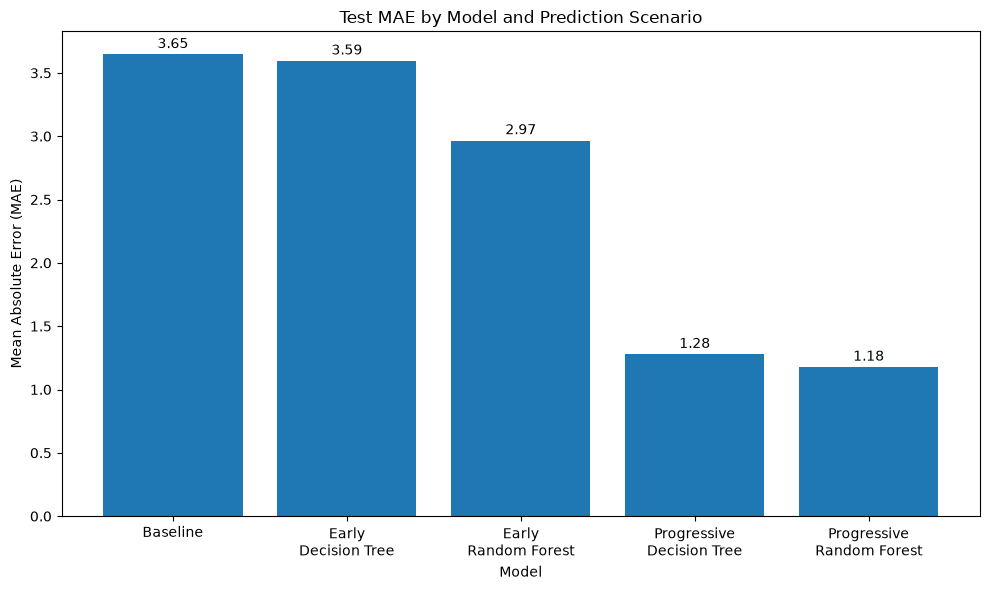

In [18]:
model_labels = [
    "Baseline",
    "Early\nDecision Tree",
    "Early\nRandom Forest",
    "Progressive\nDecision Tree",
    "Progressive\nRandom Forest"
]

mae_values = [
    baseline_mae,
    early_tree_mae,
    early_forest_mae,
    progressive_tree_mae,
    progressive_forest_mae
]

plt.figure(figsize=(10, 6))

bars = plt.bar(model_labels, mae_values)

plt.title("Test MAE by Model and Prediction Scenario")
plt.ylabel("Mean Absolute Error (MAE)")
plt.xlabel("Model")

for bar, value in zip(bars, mae_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Test R² Comparison

R² is compared across the initial models to evaluate how effectively each model explains variation in final student grades.

Models with values closer to 1 provide stronger predictive performance, while values near or below 0 indicate limited improvement over a simple mean prediction.

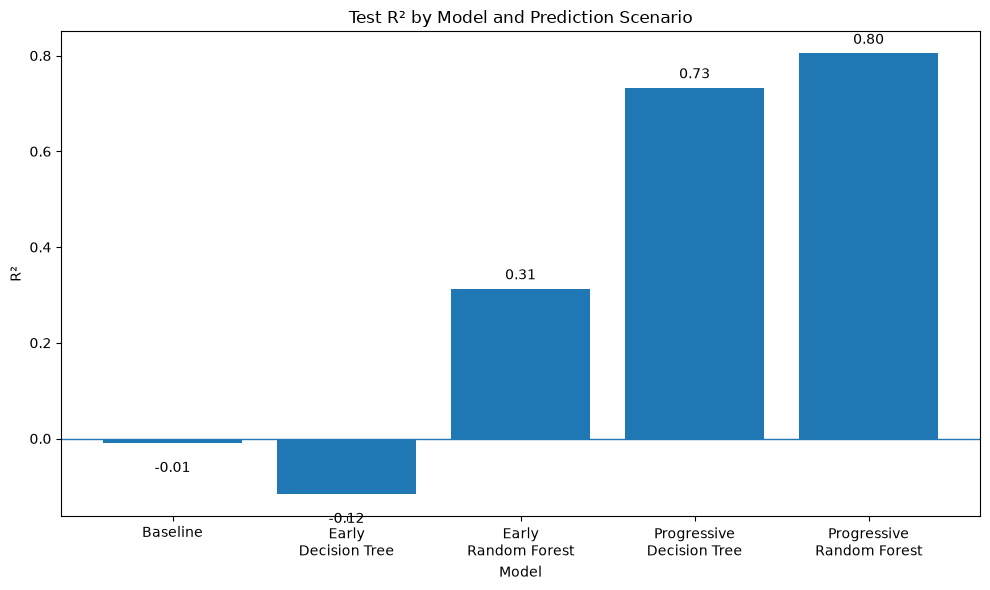

In [19]:
r2_values = [
    baseline_r2,
    early_tree_r2,
    early_forest_r2,
    progressive_tree_r2,
    progressive_forest_r2
]

plt.figure(figsize=(10, 6))

bars = plt.bar(model_labels, r2_values)

plt.axhline(0, linewidth=1)

plt.title("Test R² by Model and Prediction Scenario")
plt.ylabel("R²")
plt.xlabel("Model")

for bar, value in zip(bars, r2_values):
    y_position = value + 0.02 if value >= 0 else value - 0.06

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_position,
        f"{value:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Impact of Previous Academic Performance

Exploratory analysis identified `G1` and `G2` as the numerical variables most strongly correlated with the final grade.

To quantify their predictive contribution, the performance of the Early and Progressive Random Forest models is compared directly.

In [20]:
mae_reduction = (
    (early_forest_mae - progressive_forest_mae)
    / early_forest_mae
) * 100

r2_improvement = (
    progressive_forest_r2 - early_forest_r2
)

print(
    f"Early Random Forest MAE: "
    f"{early_forest_mae:.3f}"
)

print(
    f"Progressive Random Forest MAE: "
    f"{progressive_forest_mae:.3f}"
)

print(
    f"\nMAE reduction after adding G1 and G2: "
    f"{mae_reduction:.1f}%"
)

print(
    f"R² increase after adding G1 and G2: "
    f"{r2_improvement:.3f}"
)

Early Random Forest MAE: 2.966
Progressive Random Forest MAE: 1.178

MAE reduction after adding G1 and G2: 60.3%
R² increase after adding G1 and G2: 0.492


## Initial Modeling Findings

The initial experiments reveal several important patterns:

- The baseline model achieved an MAE of approximately **3.65** and an R² near **0**, establishing a simple benchmark for model performance.
- The unrestricted Early Decision Tree achieved perfect training performance but performed poorly on unseen data, indicating substantial overfitting.
- The Early Random Forest generalized better than the Early Decision Tree, achieving an MAE of approximately **2.97** and an R² of approximately **0.31**.
- Including previous grades (`G1` and `G2`) substantially improved predictive performance.
- The Progressive Decision Tree achieved an MAE of approximately **1.28** and an R² of approximately **0.73**.
- The Progressive Random Forest produced the strongest initial test performance, with an MAE of approximately **1.18** and an R² of approximately **0.81**.
- Comparing the two Random Forest scenarios, adding `G1` and `G2` reduced test MAE by approximately **60%**, demonstrating that recent academic performance contributes substantial predictive information.

The training-test performance gaps also indicate that the tree-based models, particularly unrestricted Decision Trees, are susceptible to overfitting on this relatively small dataset. The next stage therefore evaluates model regularization and hyperparameter tuning.

## Actual vs. Predicted Final Grades

The Progressive Random Forest currently provides the strongest test performance.

Plotting predicted grades against actual grades provides a visual assessment of prediction quality. Predictions closer to the diagonal reference line represent more accurate estimates.

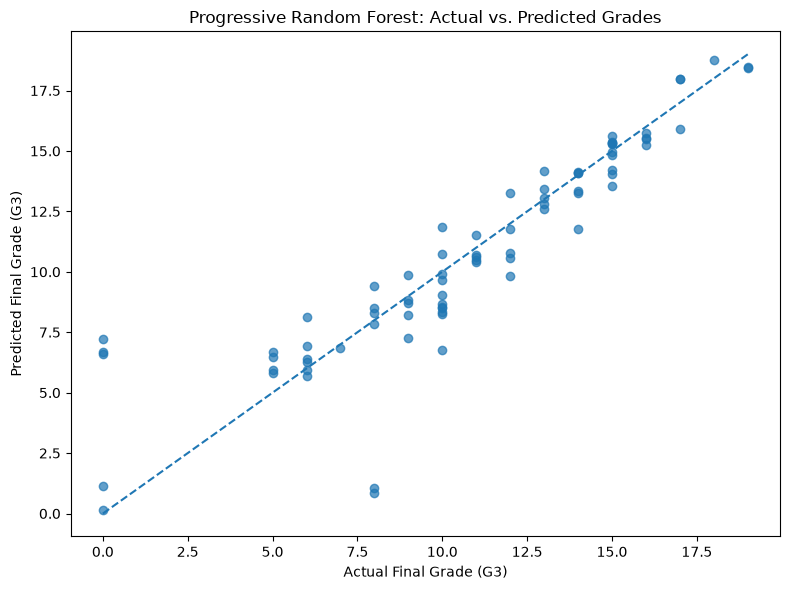

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    progressive_forest_predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title(
    "Progressive Random Forest: Actual vs. Predicted Grades"
)

plt.xlabel("Actual Final Grade (G3)")
plt.ylabel("Predicted Final Grade (G3)")

plt.tight_layout()
plt.show()

### Prediction Error Analysis

Individual predictions are examined to understand where the model performs well and where larger errors occur.

The absolute prediction error represents the distance between the predicted and actual final grade for each student.

In [22]:
prediction_analysis = pd.DataFrame({
    "Actual G3": y_test.values,
    "Predicted G3": progressive_forest_predictions
})

prediction_analysis["Error"] = (
    prediction_analysis["Actual G3"]
    - prediction_analysis["Predicted G3"]
)

prediction_analysis["Absolute Error"] = (
    prediction_analysis["Error"].abs()
)

prediction_analysis.head(10).round(2)

,Actual G3,Predicted G3,Error,Absolute Error
0,10,8.28,1.72,1.72
1,12,11.78,0.21,0.21
2,5,6.70,-1.70,1.70
3,10,9.68,0.32,0.32
4,9,8.84,0.16,0.16
5,13,12.80,0.21,0.21
6,18,18.77,-0.77,0.77
7,6,6.92,-0.92,0.92
8,0,7.20,-7.20,7.20
9,14,13.28,0.72,0.72


### Largest Prediction Errors

The observations with the largest absolute errors are inspected to identify cases where the model has difficulty estimating final performance.

In [23]:
prediction_analysis.sort_values(
    "Absolute Error",
    ascending=False
).head(10).round(2)

,Actual G3,Predicted G3,Error,Absolute Error
8,0,7.20,-7.20,7.20
34,8,0.83,7.17,7.17
16,8,1.04,6.96,6.96
19,0,6.66,-6.66,6.66
24,0,6.62,-6.62,6.62
45,10,6.78,3.22,3.22
38,14,11.76,2.23,2.23
27,12,9.82,2.18,2.18
70,6,8.14,-2.14,2.14
13,10,11.86,-1.86,1.86


## Cross-Validation

The initial train-test results provide a useful comparison, but performance based on a single split can vary depending on which students appear in the training and testing sets.

Five-fold cross-validation is therefore used on the training data to estimate how consistently each model performs across multiple subsets of students.

The held-out test set remains untouched during this process and will be used only for final evaluation.

In [26]:
def evaluate_cv(model, X, y, cv=5):
    mae_scores = -cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    r2_scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="r2",
        n_jobs=-1
    )

    return {
        "MAE Mean": mae_scores.mean(),
        "MAE Std": mae_scores.std(),
        "R² Mean": r2_scores.mean(),
        "R² Std": r2_scores.std()
    }

In [27]:
cv_results = []

models_for_cv = [
    (
        "Early Decision Tree",
        early_tree_pipeline,
        X_early_train
    ),
    (
        "Progressive Decision Tree",
        progressive_tree_pipeline,
        X_progressive_train
    ),
    (
        "Early Random Forest",
        early_forest_pipeline,
        X_early_train
    ),
    (
        "Progressive Random Forest",
        progressive_forest_pipeline,
        X_progressive_train
    )
]

for name, model, X_train in models_for_cv:
    scores = evaluate_cv(
        model,
        X_train,
        y_train
    )

    scores["Model"] = name
    cv_results.append(scores)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df[
    [
        "Model",
        "MAE Mean",
        "MAE Std",
        "R² Mean",
        "R² Std"
    ]
]

cv_results_df.round(3)

,Model,MAE Mean,MAE Std,R² Mean,R² Std
0,Early Decision Tree,4.048,0.397,-0.483,0.432
1,Progressive Decision Tree,1.079,0.189,0.804,0.082
2,Early Random Forest,2.900,0.235,0.276,0.055
3,Progressive Random Forest,0.922,0.086,0.902,0.027


## Decision Tree Regularization

The unrestricted Decision Trees perfectly fit the training data, indicating severe overfitting.

Tree complexity is therefore controlled using hyperparameters such as:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

Grid search with cross-validation is used to identify a combination that improves generalization.

In [28]:
progressive_tree_param_grid = {
    "model__max_depth": [
        3,
        4,
        5,
        6,
        8,
        None
    ],
    "model__min_samples_split": [
        2,
        5,
        10,
        20
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4,
        8
    ]
}

In [29]:
progressive_tree_grid = GridSearchCV(
    estimator=progressive_tree_pipeline,
    param_grid=progressive_tree_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

progressive_tree_grid.fit(
    X_progressive_train,
    y_train
)

print(
    "Best Progressive Decision Tree Parameters:"
)

print(
    progressive_tree_grid.best_params_
)

print(
    "Best CV MAE:",
    round(
        -progressive_tree_grid.best_score_,
        3
    )
)

Best Progressive Decision Tree Parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Best CV MAE: 0.975


### Tuned Progressive Decision Tree

The best Decision Tree configuration selected through cross-validation is evaluated on the held-out test set.

In [30]:
best_progressive_tree = (
    progressive_tree_grid.best_estimator_
)

tuned_tree_predictions = (
    best_progressive_tree.predict(
        X_progressive_test
    )
)

tuned_tree_mae = mean_absolute_error(
    y_test,
    tuned_tree_predictions
)

tuned_tree_r2 = r2_score(
    y_test,
    tuned_tree_predictions
)

print(
    f"Tuned Decision Tree MAE: "
    f"{tuned_tree_mae:.3f}"
)

print(
    f"Tuned Decision Tree R²: "
    f"{tuned_tree_r2:.3f}"
)

Tuned Decision Tree MAE: 1.341
Tuned Decision Tree R²: 0.718


In [31]:
tuned_tree_train_predictions = (
    best_progressive_tree.predict(
        X_progressive_train
    )
)

tuned_tree_train_mae = mean_absolute_error(
    y_train,
    tuned_tree_train_predictions
)

tuned_tree_train_r2 = r2_score(
    y_train,
    tuned_tree_train_predictions
)

print("TUNED PROGRESSIVE DECISION TREE")
print("--------------------------------")

print(
    f"Training MAE: "
    f"{tuned_tree_train_mae:.3f}"
)

print(
    f"Training R²:  "
    f"{tuned_tree_train_r2:.3f}"
)

print()

print(
    f"Testing MAE:  "
    f"{tuned_tree_mae:.3f}"
)

print(
    f"Testing R²:   "
    f"{tuned_tree_r2:.3f}"
)

TUNED PROGRESSIVE DECISION TREE
--------------------------------
Training MAE: 0.530
Training R²:  0.966

Testing MAE:  1.341
Testing R²:   0.718


## Random Forest Hyperparameter Tuning

The Progressive Random Forest currently provides the strongest predictive performance.

Grid search is used to evaluate several model configurations while controlling tree depth, minimum sample requirements, feature sampling, and the number of trees.

Cross-validation is performed only on the training data so that the test set remains independent for final evaluation.

In [32]:
progressive_forest_param_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    "model__max_depth": [
        None,
        5,
        8,
        12
    ],
    "model__min_samples_split": [
        2,
        5,
        10
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4
    ],
    "model__max_features": [
        "sqrt",
        0.5,
        1.0
    ]
}

In [33]:
progressive_forest_grid = GridSearchCV(
    estimator=progressive_forest_pipeline,
    param_grid=progressive_forest_param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1
)

progressive_forest_grid.fit(
    X_progressive_train,
    y_train
)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__max_features': ['sqrt', 0.5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more

In [34]:
print(
    "Best Progressive Random Forest Parameters:"
)

print(
    progressive_forest_grid.best_params_
)

print(
    "Best CV MAE:",
    round(
        -progressive_forest_grid.best_score_,
        3
    )
)

Best Progressive Random Forest Parameters:
{'model__max_depth': 8, 'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV MAE: 0.909


### Tuned Progressive Random Forest

The best Random Forest configuration selected through cross-validation is evaluated on the held-out test set and compared with the original untuned model.

In [35]:
best_progressive_forest = (
    progressive_forest_grid.best_estimator_
)

tuned_forest_predictions = (
    best_progressive_forest.predict(
        X_progressive_test
    )
)

tuned_forest_mae = mean_absolute_error(
    y_test,
    tuned_forest_predictions
)

tuned_forest_r2 = r2_score(
    y_test,
    tuned_forest_predictions
)

print(
    f"Tuned Random Forest MAE: "
    f"{tuned_forest_mae:.3f}"
)

print(
    f"Tuned Random Forest R²: "
    f"{tuned_forest_r2:.3f}"
)

Tuned Random Forest MAE: 1.172
Tuned Random Forest R²: 0.809


In [36]:
tuned_forest_train_predictions = (
    best_progressive_forest.predict(
        X_progressive_train
    )
)

tuned_forest_train_mae = mean_absolute_error(
    y_train,
    tuned_forest_train_predictions
)

tuned_forest_train_r2 = r2_score(
    y_train,
    tuned_forest_train_predictions
)

print("TUNED PROGRESSIVE RANDOM FOREST")
print("--------------------------------")

print(
    f"Training MAE: "
    f"{tuned_forest_train_mae:.3f}"
)

print(
    f"Training R²:  "
    f"{tuned_forest_train_r2:.3f}"
)

print()

print(
    f"Testing MAE:  "
    f"{tuned_forest_mae:.3f}"
)

print(
    f"Testing R²:   "
    f"{tuned_forest_r2:.3f}"
)

TUNED PROGRESSIVE RANDOM FOREST
--------------------------------
Training MAE: 0.380
Training R²:  0.983

Testing MAE:  1.172
Testing R²:   0.809


## Final Model Comparison

The tuned models are compared with their original versions to determine whether hyperparameter optimization improved generalization.

Model selection is based primarily on performance on the held-out test set, while cross-validation results provide additional evidence about stability across different training subsets.

In [37]:
final_model_results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Early Decision Tree",
        "Early Random Forest",
        "Progressive Decision Tree",
        "Tuned Progressive Decision Tree",
        "Progressive Random Forest",
        "Tuned Progressive Random Forest"
    ],
    "MAE": [
        baseline_mae,
        early_tree_mae,
        early_forest_mae,
        progressive_tree_mae,
        tuned_tree_mae,
        progressive_forest_mae,
        tuned_forest_mae
    ],
    "R²": [
        baseline_r2,
        early_tree_r2,
        early_forest_r2,
        progressive_tree_r2,
        tuned_tree_r2,
        progressive_forest_r2,
        tuned_forest_r2
    ]
})

final_model_results.round(3)

,Model,MAE,R²
0,Baseline,3.646,-0.010
1,Early Decision Tree,3.595,-0.116
2,Early Random Forest,2.966,0.313
3,Progressive Decision Tree,1.278,0.733
4,Tuned Progressive Decision Tree,1.341,0.718
5,Progressive Random Forest,1.178,0.805
6,Tuned Progressive Random Forest,1.172,0.809


## Final Model Selection

The **Tuned Progressive Random Forest** is selected as the final model.

It achieved the strongest held-out test performance with approximately:

- **MAE: 1.17 grade points**
- **R²: 0.81**

The tuned model also achieved strong cross-validation performance, indicating that its predictive ability is reasonably consistent across different subsets of the training data.

The improvement from hyperparameter tuning was modest compared with the original Progressive Random Forest, suggesting that the initial Random Forest configuration was already well suited to this dataset.

## Feature Importance

Random Forest models provide feature-importance scores that estimate how much each transformed feature contributes to reducing prediction error across the ensemble.

Because categorical variables were one-hot encoded during preprocessing, the transformed feature names are recovered from the fitted preprocessing pipeline before being paired with the Random Forest importance scores.

In [38]:
final_preprocessor = (
    best_progressive_forest.named_steps["preprocessor"]
)

final_model = (
    best_progressive_forest.named_steps["model"]
)

feature_names = (
    final_preprocessor.get_feature_names_out()
)

feature_importances = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

feature_importances = (
    feature_importances
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importances.head(15)

,Feature,Importance
0,numerical__G2,0.793906
1,numerical__absences,0.109540
2,categorical__reason_home,0.019061
3,numerical__age,0.011352
4,numerical__G1,0.006894
5,numerical__famrel,0.004148
6,numerical__goout,0.003967
7,numerical__health,0.003940
8,categorical__reason_course,0.003877
9,numerical__studytime,0.003009


In [39]:
feature_importances["Feature"] = (
    feature_importances["Feature"]
    .str.replace(
        "numerical__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

feature_importances.head(15)

,Feature,Importance
0,G2,0.793906
1,absences,0.109540
2,reason_home,0.019061
3,age,0.011352
4,G1,0.006894
5,famrel,0.004148
6,goout,0.003967
7,health,0.003940
8,reason_course,0.003877
9,studytime,0.003009


### Most Important Predictors

The highest-ranked feature-importance scores are visualized to identify which variables contribute most strongly to the final Random Forest predictions.

Feature importance indicates predictive contribution within the model and should not be interpreted as evidence of causation.

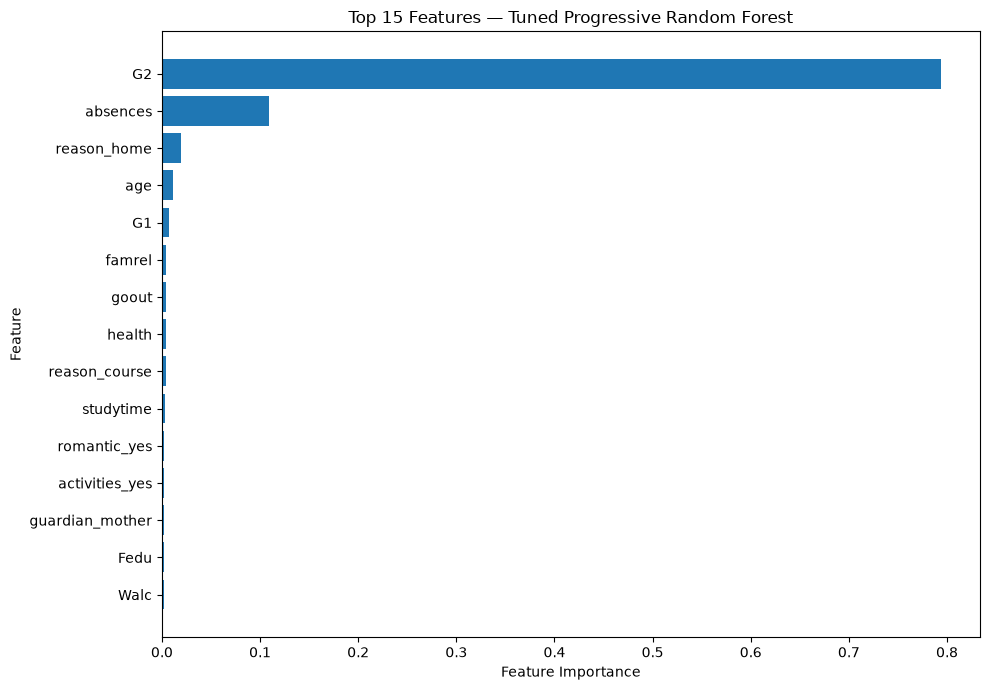

In [40]:
top_features = (
    feature_importances
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 15 Features — Tuned Progressive Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Investigating Zero Final Grades

Several of the largest prediction errors involve students whose recorded final grade (`G3`) is zero.

These observations are examined to understand whether their previous grades and other academic characteristics differ from typical cases. This helps determine whether the model's large errors may reflect unusual patterns in the dataset.

In [41]:
zero_grade_students = df[df["G3"] == 0]

print(
    "Number of students with G3 = 0:",
    len(zero_grade_students)
)

zero_grade_students[
    [
        "G1",
        "G2",
        "G3",
        "failures",
        "studytime",
        "absences"
    ]
].head(20)

Number of students with G3 = 0: 38


,G1,G2,G3,failures,studytime,absences
128,7,4,0,2,1,0
130,12,0,0,2,3,0
131,8,0,0,0,1,0
134,9,0,0,0,2,0
135,11,0,0,0,3,0
136,10,0,0,0,2,0
137,4,0,0,2,1,0
140,7,9,0,0,4,0
144,5,0,0,3,1,0
146,6,7,0,3,2,0


In [42]:
zero_grade_students[
    ["G1", "G2", "G3"]
].describe()

,G1,G2,G3
count,38.000000,38.000000,38.0
mean,7.526316,4.657895,0.0
std,1.811925,3.700083,0.0
min,4.000000,0.000000,0.0
25%,6.000000,0.000000,0.0
50%,7.000000,5.000000,0.0
75%,9.000000,8.000000,0.0
max,12.000000,10.000000,0.0


In [43]:
nonzero_grade_students = df[
    df["G3"] > 0
]

print("ZERO G3 STUDENTS")

print(
    zero_grade_students[
        ["G1", "G2"]
    ].mean()
)

print("\nNON-ZERO G3 STUDENTS")

print(
    nonzero_grade_students[
        ["G1", "G2"]
    ].mean()
)

ZERO G3 STUDENTS
G1    7.526316
G2    4.657895
dtype: float64

NON-ZERO G3 STUDENTS
G1    11.268908
G2    11.358543
dtype: float64


## Residual Analysis

Residuals represent the difference between actual and predicted final grades.

Examining residuals helps reveal whether prediction errors are centered around zero and whether the model shows systematic patterns of underprediction or overprediction.

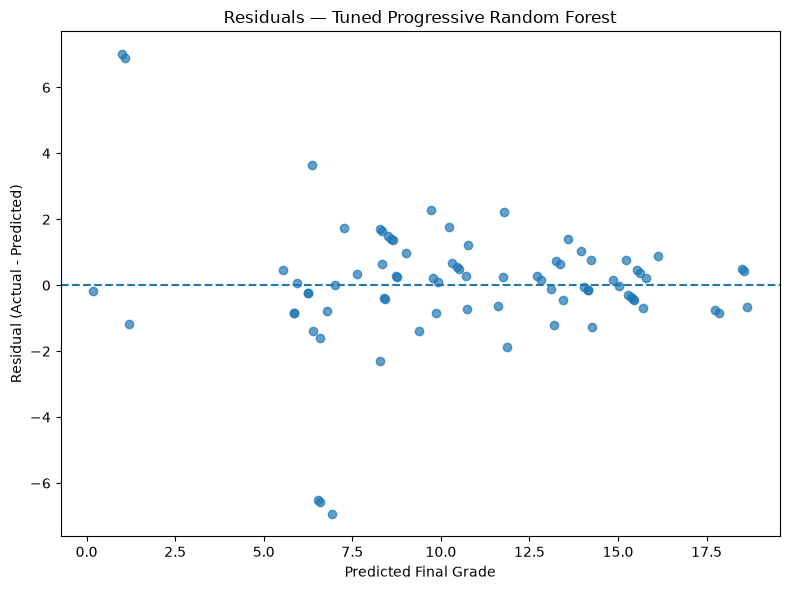

In [44]:
final_residuals = (
    y_test.values
    - tuned_forest_predictions
)

plt.figure(figsize=(8, 6))

plt.scatter(
    tuned_forest_predictions,
    final_residuals,
    alpha=0.7
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "Residuals — Tuned Progressive Random Forest"
)

plt.xlabel("Predicted Final Grade")
plt.ylabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.show()

In [45]:
print(
    f"Mean residual: "
    f"{final_residuals.mean():.3f}"
)

print(
    f"Residual standard deviation: "
    f"{final_residuals.std():.3f}"
)

Mean residual: 0.063
Residual standard deviation: 1.980


## Save the Final Model

The complete tuned pipeline, including categorical preprocessing and the trained Random Forest model, is serialized using Joblib.

Saving the complete pipeline ensures that future predictions apply the same preprocessing steps used during training.

In [49]:
MODEL_PATH = (
    "../models/"
    "student_performance_random_forest.joblib"
)

joblib.dump(
    best_progressive_forest,
    MODEL_PATH
)

print(
    f"Model saved to: {MODEL_PATH}"
)

Model saved to: ../models/student_performance_random_forest.joblib


In [50]:
loaded_model = joblib.load(
    MODEL_PATH
)

verification_predictions = (
    loaded_model.predict(
        X_progressive_test
    )
)

print(
    "Predictions identical:",
    np.allclose(
        tuned_forest_predictions,
        verification_predictions
    )
)

Predictions identical: True
